# FNO Channel Design v5 — Final

## Honest assessment of previous attempts

| Version | Ch1 | Ch2 | Ch3 | Verdict |
|---|---|---|---|---|
| v2 | irfft2(log PSD) | irfft2(phase) | Radial dev | Ch1,Ch2 = artifacts |
| v3 | Bandpass (hard mask) | Azimuthal std per ring | Radial dev | Ch1 ringing, Ch2 scalar-per-ring |
| v4 | Gaussian bandpass | Angular gradient | Radial dev | Ch1 = redundant with raw |
| **v5** | **Polar transform** | **Angular gradient** | **Radial deviation** | **All non-redundant** |

## Why Ch1 was always nearly redundant

Gaussian bandpass of a lensing arc just returns the arc — the arc IS the mid-frequency content.
Any filtered version of the raw carries the same spatial structure.

## Final channel design

| Ch | What | Why non-redundant |
|---|---|---|
| 0 | Raw (Cartesian) | Absolute flux, standard spatial view |
| 1 | **Polar transform** | Maps ring → horizontal line. FNO's spectral conv sees ring periodicity as a pure frequency — directly exploitable. The polar image looks completely different from the Cartesian raw. |
| 2 | Angular gradient `\|dI/dθ\|` | Per-pixel angular intensity change — substructure position marker |
| 3 | Radial deviation | Per-pixel radial symmetry breaking — confirmed working |

The polar transform is the key insight: a circular Einstein ring becomes a **horizontal stripe** in polar space.
Subhalo perturbation becomes a **vertical spike**. Vortex becomes a **wavy stripe**.
FNO's Fourier modes directly encode these as pure spatial frequencies — far easier to classify.

In [1]:
import numpy as np
import os
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torchvision.transforms as transforms
import torch.nn.functional as F
import random

class LensDatasetFNO(Dataset):
    """
    Final 4-channel FNO input:

    Ch 0 — Raw (Cartesian)        absolute flux
    Ch 1 — Polar transform        ring → stripe, substructure → spike/wave
    Ch 2 — Angular gradient       |dI/dθ| per pixel
    Ch 3 — Radial deviation       |I - ring_mean| per pixel

    Augmentation pipeline (correct order):
      1. Geometric aug on raw only (before channel computation)
      2. Compute Ch1-Ch3 from augmented raw
      3. Normalize all 4 channels
      4. RandomErasing on Ch0 only
    """
    def __init__(self, root_dir, mean=None, std=None, augment=False, img_size=150):
        self.root_dir = root_dir
        self.augment  = augment
        self.mean     = mean
        self.std      = std
        self.img_size = img_size

        self.paths, self.labels = [], []
        self.classes = sorted([d for d in os.listdir(root_dir)
                                if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        for cls in self.classes:
            for f in sorted(os.listdir(os.path.join(root_dir, cls))):
                if f.endswith(".npy"):
                    self.paths.append(os.path.join(root_dir, cls, f))
                    self.labels.append(self.class_to_idx[cls])

    def __len__(self): return len(self.paths)

    def _geometric_aug(self, img):
        if random.random() > 0.5: img = TF.hflip(img)
        if random.random() > 0.5: img = TF.vflip(img)
        angle = random.uniform(-180, 180)
        img = TF.rotate(img, angle, fill=0)
        H, W = img.shape[-2], img.shape[-1]
        tx = int(random.uniform(-0.05, 0.05) * W)
        ty = int(random.uniform(-0.05, 0.05) * H)
        img = TF.affine(img, angle=0, translate=[tx, ty], scale=1.0, shear=0, fill=0)
        return img

    def _polar_transform(self, img):
        """
        Ch 1: Cartesian → Polar coordinate remapping.

        Maps (x, y) → (r, θ) so that:
          - A circular Einstein ring becomes a HORIZONTAL STRIPE
          - Subhalo perturbation becomes a VERTICAL SPIKE at its angular position
          - Vortex perturbation becomes a WAVY STRIPE

        Output shape: same as input (H, W)
          axis 0 = radial direction  (r:  0 → r_max)
          axis 1 = angular direction (θ: -π → π)

        FNO's spectral convolution in the polar image directly encodes:
          - Ring frequency: the dominant horizontal frequency (how many rings)
          - Substructure: vertical frequency components (breaks horizontal symmetry)
        """
        eps = 1e-8
        H, W = img.shape[-2], img.shape[-1]
        cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
        r_max = min(cx, cy)

        # build polar grid: r in [0, r_max], theta in [-pi, pi]
        r_vals     = torch.linspace(0, r_max, H)           # (H,)
        theta_vals = torch.linspace(-torch.pi, torch.pi, W) # (W,)

        R, THETA = torch.meshgrid(r_vals, theta_vals, indexing='ij')  # (H, W)

        # convert polar → Cartesian for grid_sample
        x_cart = cx + R * torch.cos(THETA)
        y_cart = cy + R * torch.sin(THETA)

        # normalise to [-1, 1] for grid_sample
        gx = (x_cart / (W - 1)) * 2 - 1
        gy = (y_cart / (H - 1)) * 2 - 1
        grid = torch.stack([gx, gy], dim=-1).unsqueeze(0)  # (1, H, W, 2)

        polar = F.grid_sample(img.unsqueeze(0), grid,
                               mode='bilinear', padding_mode='zeros',
                               align_corners=True).squeeze(0)  # (1, H, W)
        p = polar[0]
        return ((p - p.min()) / (p.max() - p.min() + eps)).unsqueeze(0)

    def _angular_gradient(self, img):
        """Ch 2: |dI/dθ| per pixel in polar coordinates."""
        eps = 1e-8
        H, W = img.shape[-2], img.shape[-1]
        cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
        ys = torch.arange(H, dtype=torch.float32).unsqueeze(1).expand(H, W)
        xs = torch.arange(W, dtype=torch.float32).unsqueeze(0).expand(H, W)
        radii  = torch.sqrt((xs - cx)**2 + (ys - cy)**2).clamp(min=1.0)
        angles = torch.atan2(ys - cy, xs - cx)
        dtheta = 0.15

        def polar_sample(r, theta):
            x = cx + r * torch.cos(theta)
            y = cy + r * torch.sin(theta)
            gx = (x / (W - 1)) * 2 - 1
            gy = (y / (H - 1)) * 2 - 1
            return torch.stack([gx, gy], dim=-1)

        I = img.unsqueeze(0)
        gp = polar_sample(radii, angles + dtheta).unsqueeze(0)
        gm = polar_sample(radii, angles - dtheta).unsqueeze(0)
        Ip = F.grid_sample(I, gp, mode='bilinear', padding_mode='zeros', align_corners=True).squeeze()
        Im = F.grid_sample(I, gm, mode='bilinear', padding_mode='zeros', align_corners=True).squeeze()
        ag = (Ip - Im).abs() / (2 * dtheta)
        return ((ag - ag.min()) / (ag.max() - ag.min() + eps)).unsqueeze(0)

    def _radial_deviation(self, img):
        """Ch 3: |I - ring_mean| per pixel."""
        eps = 1e-8
        H, W = img.shape[-2], img.shape[-1]
        cx, cy = W / 2.0, H / 2.0
        ys = torch.arange(H, dtype=torch.float32).unsqueeze(1).expand(H, W)
        xs = torch.arange(W, dtype=torch.float32).unsqueeze(0).expand(H, W)
        radii   = torch.sqrt((xs - cx)**2 + (ys - cy)**2)
        n_bins  = 30
        bin_idx = (radii / (radii.max() + eps) * n_bins).long().clamp(0, n_bins - 1)
        I = img[0]
        dev = torch.zeros_like(I)
        for b in range(n_bins):
            mask = (bin_idx == b)
            if mask.sum() > 0:
                dev[mask] = (I[mask] - I[mask].mean()).abs()
        return ((dev - dev.min()) / (dev.max() - dev.min() + eps)).unsqueeze(0)

    def _build_channels(self, raw):
        return torch.cat([
            raw,
            self._polar_transform(raw),
            self._angular_gradient(raw),
            self._radial_deviation(raw),
        ], dim=0)   # (4, H, W)

    def _normalize(self, x):
        if self.mean is None: return x
        mean = torch.tensor(self.mean, dtype=torch.float32).view(-1, 1, 1)
        std  = torch.tensor(self.std,  dtype=torch.float32).view(-1, 1, 1)
        return (x - mean) / std

    def __getitem__(self, idx):
        raw = torch.tensor(np.load(self.paths[idx]), dtype=torch.float32)
        if raw.ndim == 2: raw = raw.unsqueeze(0)
        if self.augment:
            raw = self._geometric_aug(raw)
        x = self._build_channels(raw)
        x = self._normalize(x)
        if self.augment and random.random() < 0.2:
            i, j, h, w, v = transforms.RandomErasing.get_params(
                x[0:1], scale=(0.02, 0.08), ratio=(0.3, 3.3), value=[0])
            x[0, i:i+h, j:j+w] = v
        return x, self.labels[idx]


## Visualise — one sample per class, no augmentation

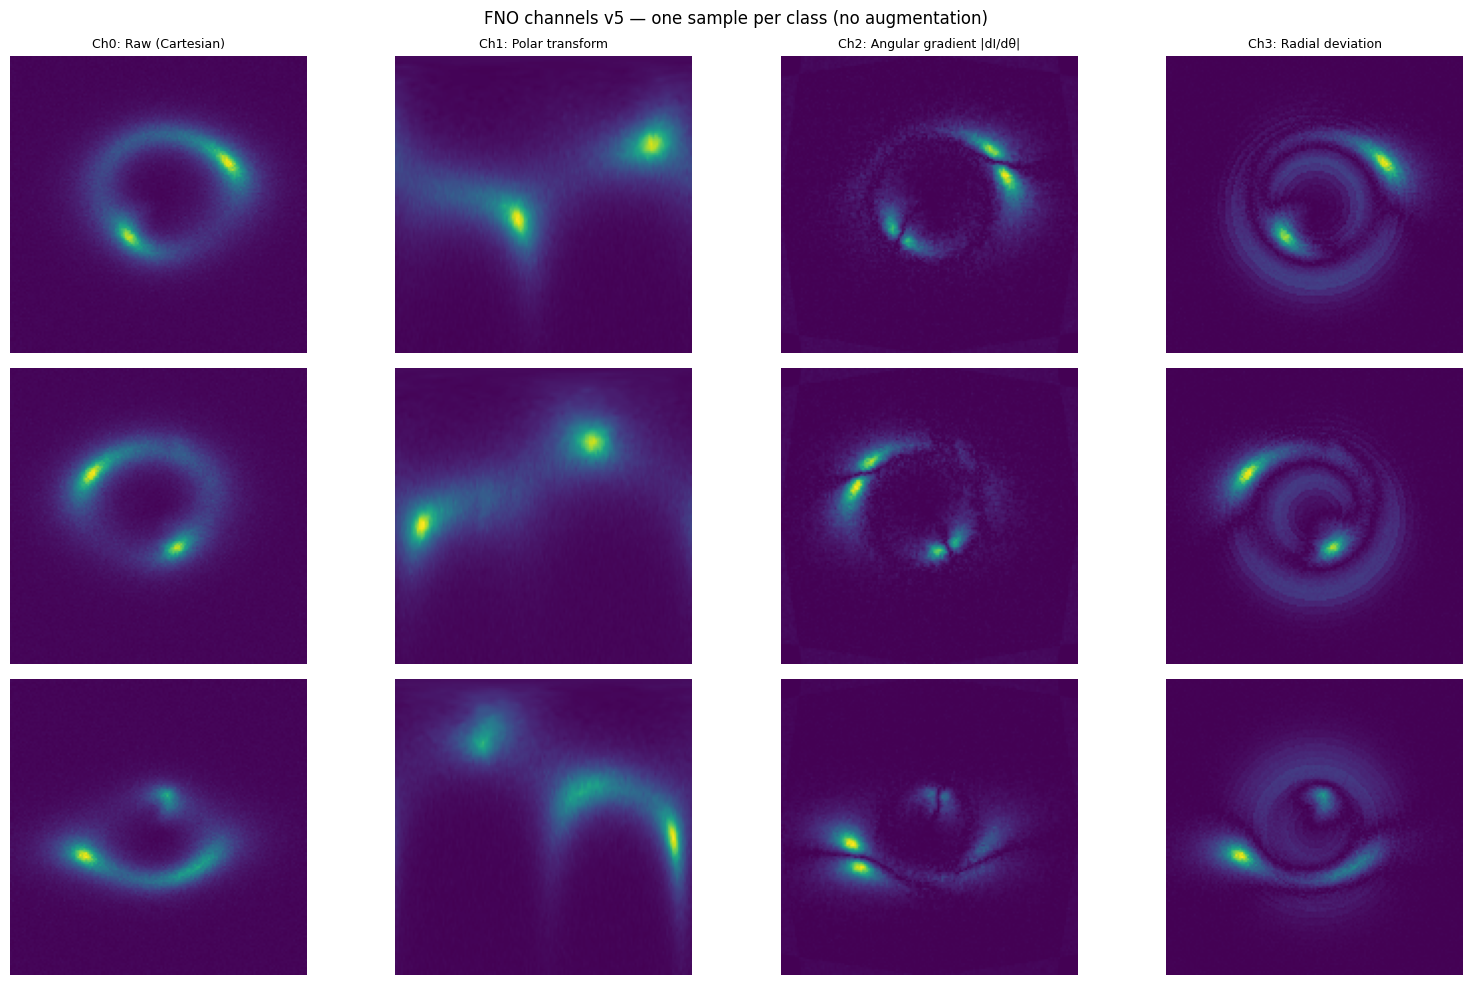

Expected:
Ch1 (Polar): no_sub=clean horizontal stripe | subhalo=stripe + vertical spike | vortex=wavy stripe
Ch2 (AngGrad): no_sub=near-zero             | subhalo=bright spot at subhalo  | vortex=arc edges
Ch3 (RadDev):  no_sub=near-zero             | subhalo=bright spot             | vortex=arc regions


In [2]:
import matplotlib.pyplot as plt

dataset_viz = LensDatasetFNO("dataset/train", augment=False)
class_names = ['no_sub', 'subhalo', 'vortex']
ch_names    = ['Ch0: Raw (Cartesian)',
               'Ch1: Polar transform',
               'Ch2: Angular gradient |dI/dθ|',
               'Ch3: Radial deviation']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for class_idx in range(3):
    # find first sample of each class
    idx = next(i for i, l in enumerate(dataset_viz.labels) if l == class_idx)
    img, _ = dataset_viz[idx]
    for ch in range(4):
        ax = axes[class_idx][ch]
        ax.imshow(img[ch].numpy(), cmap='viridis')
        if class_idx == 0: ax.set_title(ch_names[ch], fontsize=9)
        if ch == 0:        ax.set_ylabel(class_names[class_idx], fontsize=11)
        ax.axis('off')

plt.suptitle('FNO channels v5 — one sample per class (no augmentation)', fontsize=12)
plt.tight_layout()
plt.show()

print("Expected:")
print("Ch1 (Polar): no_sub=clean horizontal stripe | subhalo=stripe + vertical spike | vortex=wavy stripe")
print("Ch2 (AngGrad): no_sub=near-zero             | subhalo=bright spot at subhalo  | vortex=arc edges")
print("Ch3 (RadDev):  no_sub=near-zero             | subhalo=bright spot             | vortex=arc regions")


## Compute stats & build loaders

In [ ]:
def compute_channel_stats(root_dir, n_channels=4):
    ds = LensDatasetFNO(root_dir, augment=False)
    loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=4)
    s1 = torch.zeros(n_channels); s2 = torch.zeros(n_channels); n = 0
    for imgs, _ in loader:
        s1 += imgs.sum(dim=[0,2,3])
        s2 += (imgs**2).sum(dim=[0,2,3])
        n  += imgs.shape[0] * imgs.shape[2] * imgs.shape[3]
    mean = s1 / n
    std  = torch.sqrt((s2/n - mean**2).clamp(min=0)).clamp(min=0.0005)
    print("Mean:", [f'{m:.4f}' for m in mean.tolist()])
    print("Std :", [f'{s:.4f}' for s in std.tolist()])
    return mean.tolist(), std.tolist()

MEAN_FNO, STD_FNO = compute_channel_stats("dataset/train")

train_dataset = LensDatasetFNO("dataset/train", mean=MEAN_FNO, std=STD_FNO, augment=True)
val_dataset   = LensDatasetFNO("dataset/val",   mean=MEAN_FNO, std=STD_FNO, augment=False)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

img, label = train_dataset[0]
print(f"Shape: {img.shape}  Label: {label}")  # (4, 150, 150)
